<a href="https://colab.research.google.com/github/labib1910024/Robust-Adaptive-Multi-Class/blob/main/Robust_Adaptive_Multi_Class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

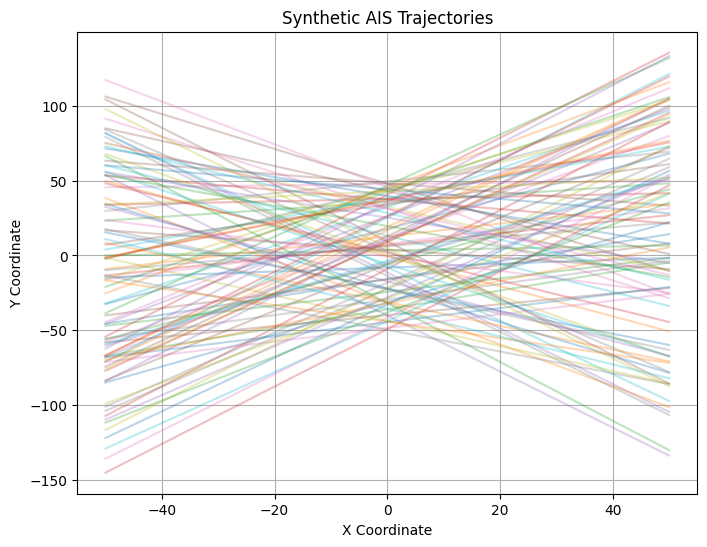

In [ ]:
# STEP 1: Synthetic AIS Trajectory Generation
import numpy as np
import matplotlib.pyplot as plt

# Number of trajectories
N = 100

# Generate random slopes and intercepts
m = np.random.uniform(-2, 2, N)
b = np.random.uniform(-50, 50, N)

# Plot trajectories
plt.figure(figsize=(8,6))

x = np.linspace(-50, 50, 100)

for i in range(N):
    y = m[i] * x + b[i]
    plt.plot(x, y, alpha=0.3)

plt.title("Synthetic AIS Trajectories")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.grid(True)

plt.show()

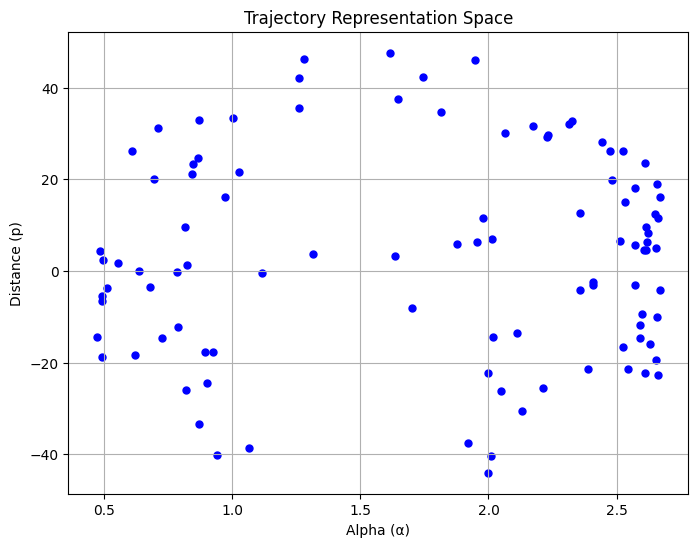

Alpha Range:
0.4710615993789231 2.6701497866444375

P Range:
-44.008208776589406 47.62443670067609


In [ ]:
# STEP 2: Trajectory Representation Space Transformation
import numpy as np
import matplotlib.pyplot as plt

# Transformation

alpha = np.pi/2 + np.arctan(m)

p = b / np.sqrt(1 + m**2)

# Plot Representation Space

plt.figure(figsize=(8,6))

plt.scatter(
    alpha,
    p,
    s=25,
    color='blue'
)

plt.title("Trajectory Representation Space")
plt.xlabel("Alpha (α)")
plt.ylabel("Distance (p)")
plt.grid(True)

plt.show()

# Optional check

print("Alpha Range:")
print(alpha.min(), alpha.max())

print("\nP Range:")
print(p.min(), p.max())

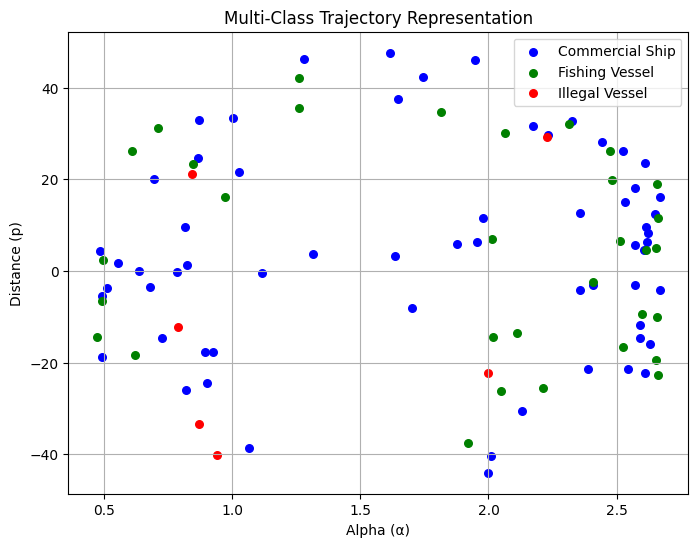

Commercial Ship : 62
Fishing Vessel : 32
Illegal Vessel : 6


In [ ]:
#STEP 3: Multi-Class Trajectory Classification
import numpy as np
import matplotlib.pyplot as plt

# Assign trajectory classes

classes = np.random.choice(
    [1,2,3],
    size=len(alpha),
    p=[0.6,0.3,0.1]
)

plt.figure(figsize=(8,6))

colors = {
    1:'blue',
    2:'green',
    3:'red'
}

labels = {
    1:'Commercial Ship',
    2:'Fishing Vessel',
    3:'Illegal Vessel'
}

for k in [1,2,3]:

    idx = classes == k

    plt.scatter(
        alpha[idx],
        p[idx],
        color=colors[k],
        label=labels[k],
        s=30
    )

plt.title(
    "Multi-Class Trajectory Representation"
)

plt.xlabel("Alpha (α)")
plt.ylabel("Distance (p)")

plt.legend()
plt.grid(True)

plt.show()

# Show class counts

for k in [1,2,3]:
    print(
        labels[k],
        ":",
        np.sum(classes==k)
    )

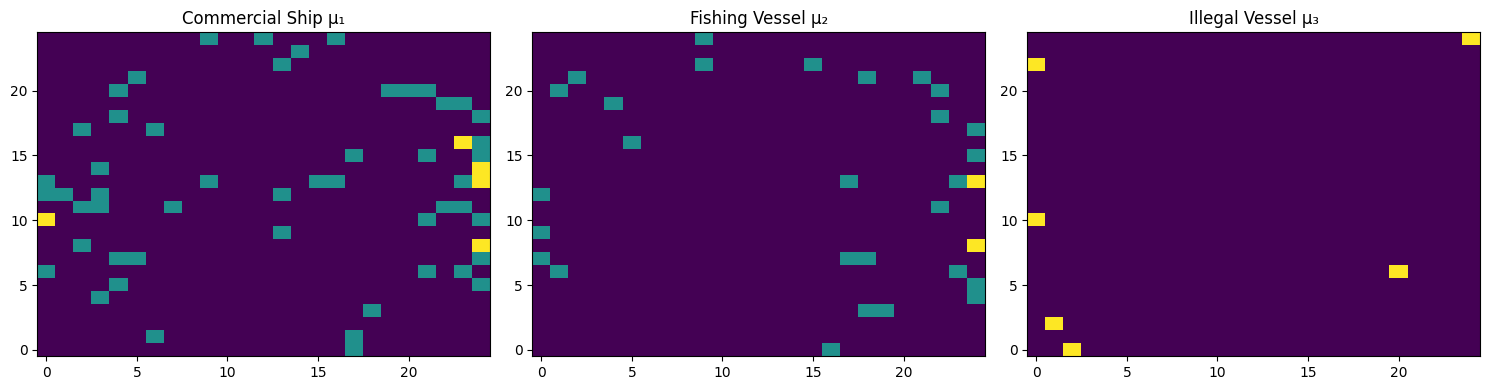

In [ ]:
# STEP 4: Multi-Class LGCLP Intensity Estimation
import numpy as np
import matplotlib.pyplot as plt

bins = 25

fig, ax = plt.subplots(
    1,
    3,
    figsize=(15,4)
)

titles = [
    "Commercial Ship μ₁",
    "Fishing Vessel μ₂",
    "Illegal Vessel μ₃"
]

for k in [1,2,3]:

    idx = classes == k

    H, xedges, yedges = np.histogram2d(
        alpha[idx],
        p[idx],
        bins=bins
    )

    ax[k-1].imshow(
        H.T,
        origin='lower',
        aspect='auto'
    )

    ax[k-1].set_title(
        titles[k-1]
    )

plt.tight_layout()
plt.show()

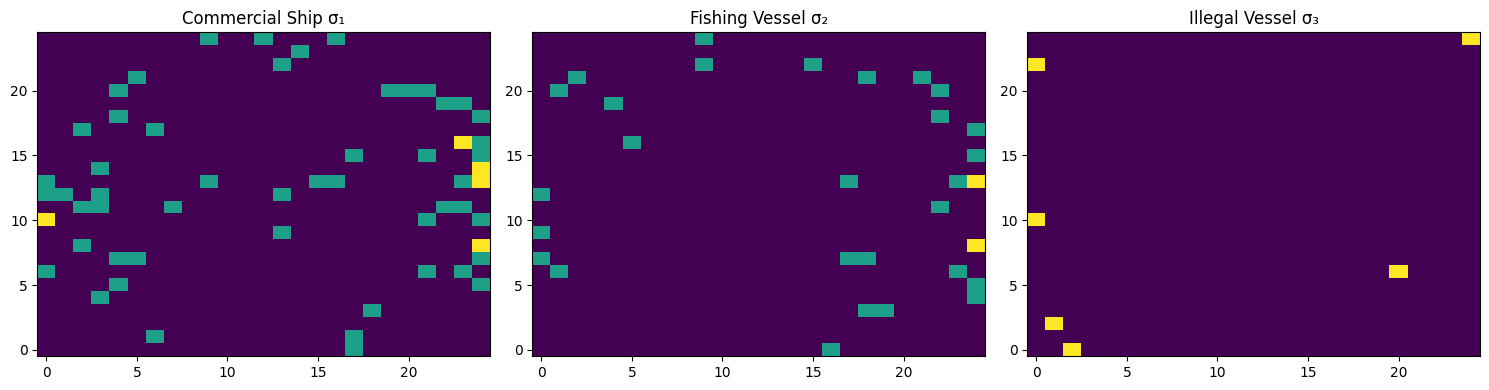

In [ ]:
# STEP 5: Intensity Uncertainty Estimation
import numpy as np
import matplotlib.pyplot as plt

bins = 25

fig, ax = plt.subplots(
    1,
    3,
    figsize=(15,4)
)

titles = [
    "Commercial Ship σ₁",
    "Fishing Vessel σ₂",
    "Illegal Vessel σ₃"
]

sigma_list = []

for k in [1,2,3]:

    idx = classes == k

    H, xedges, yedges = np.histogram2d(
        alpha[idx],
        p[idx],
        bins=bins
    )

    sigma = np.sqrt(H + 1)

    sigma_list.append(sigma)

    im = ax[k-1].imshow(
        sigma.T,
        origin='lower',
        aspect='auto'
    )

    ax[k-1].set_title(
        titles[k-1]
    )

plt.tight_layout()

plt.show()

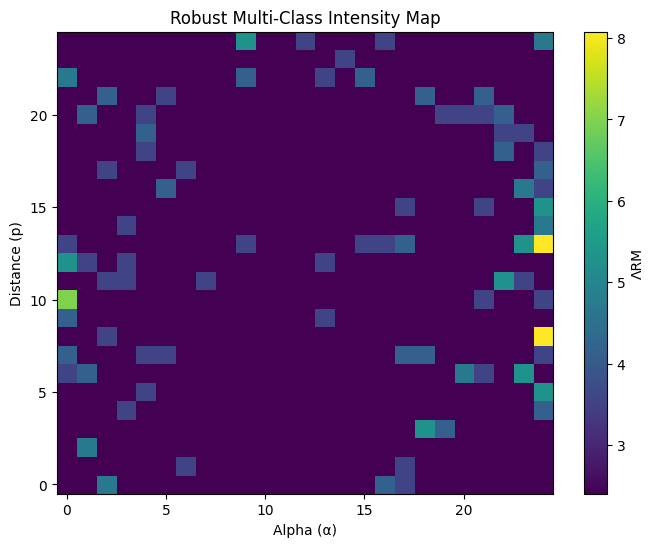

Maximum ΛRM = 8.078460969082654
Minimum ΛRM = 2.4000000000000004
Mean ΛRM = 2.6257787943213633


In [ ]:
# STEP 6: Robust Multi-Class Intensity Construction
import numpy as np
import matplotlib.pyplot as plt

bins = 25

# class weights

w1 = 1      # Commercial
w2 = 2     # Fishing
w3 = 3     # Illegal

kappa = 1

# -----------------------------------
# Commercial Ship
# -----------------------------------

idx = classes == 1

H1, _, _ = np.histogram2d(
    alpha[idx],
    p[idx],
    bins=bins
)

mu1 = H1

sigma1 = np.sqrt(H1 + 1)

# -----------------------------------
# Fishing Vessel
# -----------------------------------

idx = classes == 2

H2, _, _ = np.histogram2d(
    alpha[idx],
    p[idx],
    bins=bins
)

mu2 = H2

sigma2 = np.sqrt(H2 + 1)

# -----------------------------------
# Illegal Vessel
# -----------------------------------

idx = classes == 3

H3, _, _ = np.histogram2d(
    alpha[idx],
    p[idx],
    bins=bins
)

mu3 = H3

sigma3 = np.sqrt(H3 + 1)

# -----------------------------------
# Robust Multi-Class Intensity
# -----------------------------------

mu_total = mu1 + mu2 + mu3

Lambda_RM = (
    0.6 * mu_total
    +
    0.4 * (
        w1*(mu1 + kappa*sigma1)
        + w2*(mu2 + kappa*sigma2)
        + w3*(mu3 + kappa*sigma3)
    )
)

# -----------------------------------
# Plot
# -----------------------------------

plt.figure(figsize=(8,6))

plt.imshow(
    Lambda_RM.T,
    origin='lower',
    aspect='auto'
)

plt.colorbar(
    label='ΛRM'
)

plt.title(
    'Robust Multi-Class Intensity Map'
)

plt.xlabel('Alpha (α)')
plt.ylabel('Distance (p)')

plt.show()

# Statistics

print("Maximum ΛRM =", np.max(Lambda_RM))
print("Minimum ΛRM =", np.min(Lambda_RM))
print("Mean ΛRM =", np.mean(Lambda_RM))

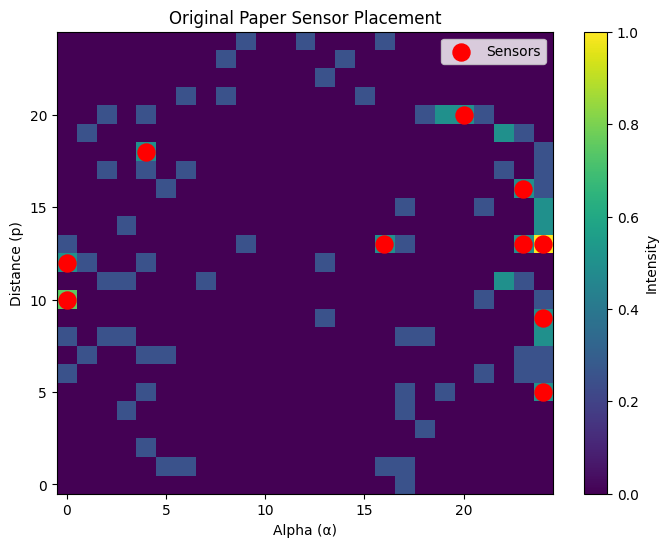

Sensor X: [np.int64(20), np.int64(24), np.int64(4), np.int64(24), np.int64(0), np.int64(16), np.int64(23), np.int64(23), np.int64(0), np.int64(24)]
Sensor Y: [np.int64(20), np.int64(9), np.int64(18), np.int64(5), np.int64(12), np.int64(13), np.int64(13), np.int64(16), np.int64(10), np.int64(13)]


In [ ]:
# STEP 7: Original LGCLP-Based Sensor Placement
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Original intensity map
# -----------------------------

H_all, _, _ = np.histogram2d(
    alpha,
    p,
    bins=25
)

# -----------------------------
# Select strongest cells
# -----------------------------

num_sensors = 10

flat_indices = np.argsort(
    H_all.ravel()
)[-num_sensors:]

sensor_x = []
sensor_y = []

for idx in flat_indices:

    x = idx // H_all.shape[1]

    y = idx % H_all.shape[1]

    sensor_x.append(x)

    sensor_y.append(y)

# -----------------------------
# Plot
# -----------------------------

plt.figure(figsize=(8,6))

plt.imshow(
    H_all.T,
    origin='lower',
    aspect='auto'
)

plt.scatter(
    sensor_x,
    sensor_y,
    c='red',
    s=150,
    marker='o',
    label='Sensors'
)

plt.colorbar(
    label='Intensity'
)

plt.title(
    'Original Paper Sensor Placement'
)

plt.xlabel('Alpha (α)')
plt.ylabel('Distance (p)')

plt.legend()

plt.show()

print("Sensor X:",sensor_x)
print("Sensor Y:",sensor_y)

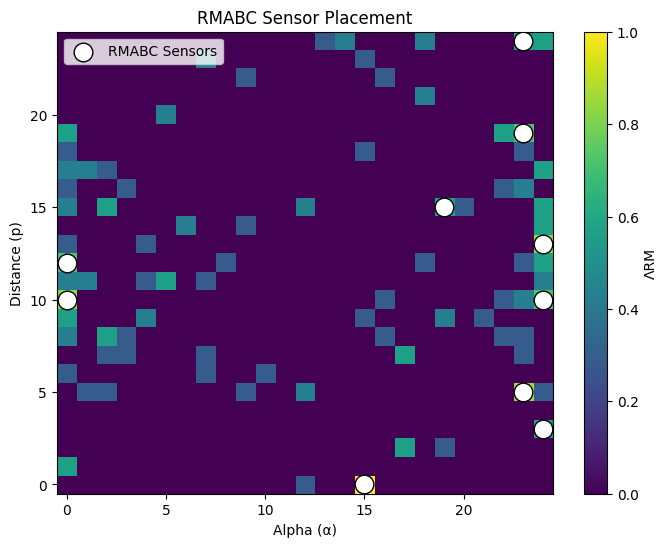

RMABC Sensor X: [np.int64(24), np.int64(23), np.int64(19), np.int64(24), np.int64(0), np.int64(23), np.int64(0), np.int64(24), np.int64(23), np.int64(15)]
RMABC Sensor Y: [np.int64(3), np.int64(24), np.int64(15), np.int64(10), np.int64(12), np.int64(19), np.int64(10), np.int64(13), np.int64(5), np.int64(0)]


In [ ]:
#STEP 8: RMABC Sensor Placement
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------
# Select strongest RMABC cells
# ----------------------------------

num_sensors = 10

flat_indices = np.argsort(
    Lambda_RM.ravel()
)[-num_sensors:]

sensor_x_rm = []
sensor_y_rm = []

for idx in flat_indices:

    x = idx // Lambda_RM.shape[1]

    y = idx % Lambda_RM.shape[1]

    sensor_x_rm.append(x)
    sensor_y_rm.append(y)

# ----------------------------------
# Plot
# ----------------------------------

plt.figure(figsize=(8,6))

plt.imshow(
    Lambda_RM.T,
    origin='lower',
    aspect='auto'
)

plt.scatter(
    sensor_x_rm,
    sensor_y_rm,
    c='white',
    s=180,
    marker='o',
    edgecolors='black',
    label='RMABC Sensors'
)

plt.colorbar(
    label='ΛRM'
)

plt.title(
    'RMABC Sensor Placement'
)

plt.xlabel('Alpha (α)')
plt.ylabel('Distance (p)')

plt.legend()

plt.show()

print("RMABC Sensor X:", sensor_x_rm)
print("RMABC Sensor Y:", sensor_y_rm)

Original Detection: 0.74
RMABC Detection: 0.66


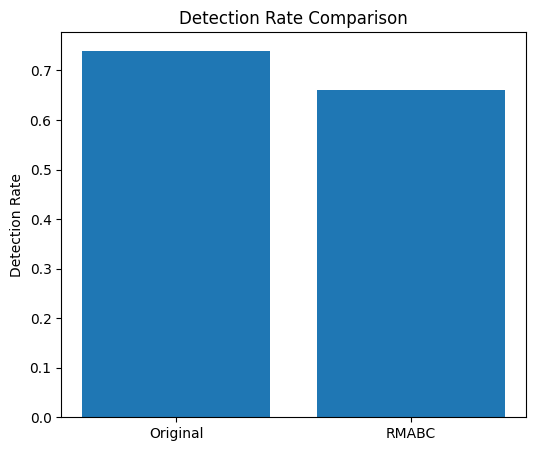

In [ ]:
# STEP 9: Detection Rate Evaluation
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# Detection Radius
# ------------------------------

radius = 6

# ------------------------------
# Original Sensors
# ------------------------------

detected_original = 0

for i in range(len(alpha)):

    x = int(alpha[i]/alpha.max()*24)

    y = int((p[i]-p.min())/
            (p.max()-p.min())*24)

    for sx,sy in zip(
            sensor_x,
            sensor_y):

        d = np.sqrt(
            (x-sx)**2 +
            (y-sy)**2
        )

        if d < radius:

            detected_original += 1

            break

# ------------------------------
# RMABC Sensors
# ------------------------------

detected_rmabc = 0

for i in range(len(alpha)):

    x = int(alpha[i]/alpha.max()*24)

    y = int((p[i]-p.min())/
            (p.max()-p.min())*24)

    for sx,sy in zip(
            sensor_x_rm,
            sensor_y_rm):

        d = np.sqrt(
            (x-sx)**2 +
            (y-sy)**2
        )

        if d < radius:

            detected_rmabc += 1

            break

# ------------------------------
# Detection Rates
# ------------------------------

rate_original = \
detected_original/len(alpha)

rate_rmabc = \
detected_rmabc/len(alpha)

print(
"Original Detection:",
rate_original
)

print(
"RMABC Detection:",
rate_rmabc
)

# ------------------------------
# Plot
# ------------------------------

plt.figure(figsize=(6,5))

plt.bar(
    ['Original',
     'RMABC'],
    [rate_original,
     rate_rmabc]
)

plt.ylabel(
'Detection Rate'
)

plt.title(
'Detection Rate Comparison'
)

plt.show()

In [ ]:
print("Original Detection =", rate_original)
print("RMABC Detection =", rate_rmabc)

Original Detection = 0.65
RMABC Detection = 0.67


Original Void Probability = 0.7046880897187134
RMABC Void Probability = 0.7189237334319262


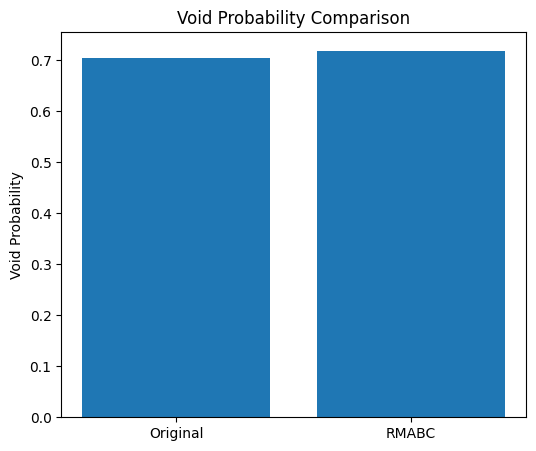

In [ ]:
# STEP 10: Void Probability Analysis
import numpy as np
import matplotlib.pyplot as plt

# ------------------------
# Original Void Probability
# ------------------------

miss_original = 1 - rate_original

void_original = np.exp(
    -miss_original
)

# ------------------------
# RMABC Void Probability
# ------------------------

miss_rmabc = 1 - rate_rmabc

void_rmabc = np.exp(
    -miss_rmabc
)

print(
    "Original Void Probability =",
    void_original
)

print(
    "RMABC Void Probability =",
    void_rmabc
)

# ------------------------
# Plot
# ------------------------

plt.figure(figsize=(6,5))

plt.bar(
    ['Original','RMABC'],
    [void_original,
     void_rmabc]
)

plt.ylabel(
    'Void Probability'
)

plt.title(
    'Void Probability Comparison'
)

plt.show()

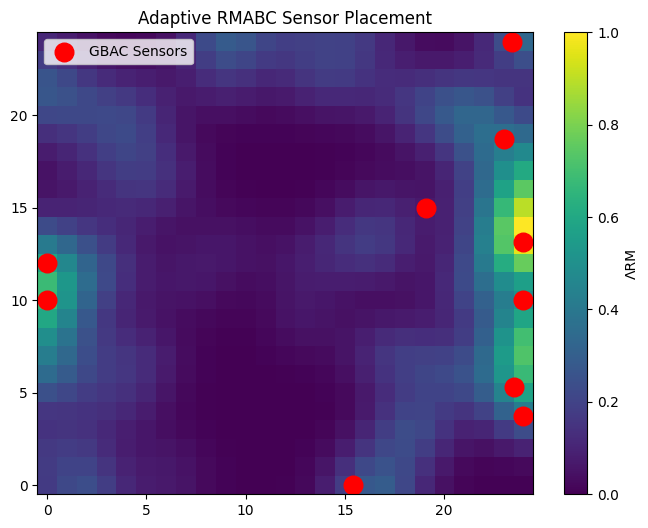

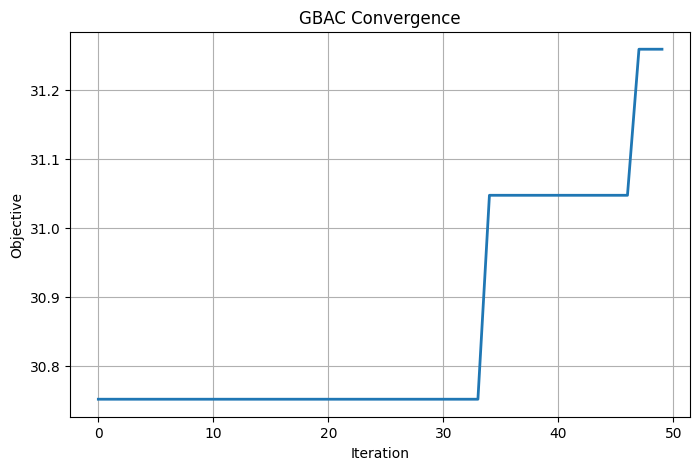

Initial Objective = 30.752170714701727
Final Objective = 31.258548704645605


In [ ]:
# STEP 11: GBAC-Based Adaptive Sensor Optimization
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Parameters
# -------------------------

eta = 0.05
iterations = 50

sensor_x = np.array(sensor_x_rm, dtype=float)
sensor_y = np.array(sensor_y_rm, dtype=float)

history = []

from scipy.ndimage import gaussian_filter

Lambda_RM_smooth = gaussian_filter(
    Lambda_RM,
    sigma=1.5
)

# -------------------------
# Objective Function
# -------------------------

def objective(sx, sy):

    score = 0

    for x, y in zip(sx, sy):

        xi = int(np.clip(round(x),0,24))
        yi = int(np.clip(round(y),0,24))

        score += Lambda_RM_smooth[xi,yi]

    return score

# -------------------------
# GBAC Optimization
# -------------------------

for step in range(iterations):

    current = objective(
        sensor_x,
        sensor_y
    )

    history.append(current)

    grad_x = np.zeros(len(sensor_x))
    grad_y = np.zeros(len(sensor_y))

    eps = 0.5

    for i in range(len(sensor_x)):

        # x gradient

        plus = sensor_x.copy()
        minus = sensor_x.copy()

        plus[i] += eps
        minus[i] -= eps

        grad_x[i] = (
            objective(plus,sensor_y)
            -
            objective(minus,sensor_y)
        )/(2*eps)

        # y gradient

        plus = sensor_y.copy()
        minus = sensor_y.copy()

        plus[i] += eps
        minus[i] -= eps

        grad_y[i] = (
            objective(sensor_x,plus)
            -
            objective(sensor_x,minus)
        )/(2*eps)

    # update sensors

    sensor_x += eta*grad_x
    sensor_y += eta*grad_y

    # keep inside map

    sensor_x = np.clip(
        sensor_x,
        0,
        24
    )

    sensor_y = np.clip(
        sensor_y,
        0,
        24
    )

# -------------------------
# Final Sensor Placement
# -------------------------

plt.figure(figsize=(8,6))

plt.imshow(
    Lambda_RM_smooth.T,
    origin='lower',
    aspect='auto'
)

plt.scatter(
    sensor_x,
    sensor_y,
    c='red',
    s=180,
    label='GBAC Sensors'
)

plt.colorbar(label='ΛRM')

plt.title(
    'Adaptive RMABC Sensor Placement'
)

plt.legend()

plt.show()

# -------------------------
# Convergence Curve
# -------------------------

plt.figure(figsize=(8,5))

plt.plot(
    history,
    linewidth=2
)

plt.xlabel('Iteration')
plt.ylabel('Objective')

plt.title(
    'GBAC Convergence'
)

plt.grid(True)

plt.show()

print(
    "Initial Objective =",
    history[0]
)

print(
    "Final Objective =",
    history[-1]
)